<a href="https://colab.research.google.com/github/LeoFairley123/EMSC2010-Individual-Project/blob/main/EMSC2010_Individual_Project_U7488277.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Title**

## Project Overview

**Three-Layer Earth Energy Balance Model**

I constructed a three-layer energy balance model representing interactions between the atmosphere, the surface (land + upper ocean), and the deep ocean. The system is driven by radiative forcing, ocean heat uptake, and time-varying external forcing.

**Model Structure**

The model consists of three coupled temperature variables:

* $T_a$: atmospheric temperature
* $T_s$: surface temperature (land + mixed ocean layer)
* $T_d$: deep ocean temperature

Energy conservation is applied to each layer, balancing incoming and outgoing radiative and turbulent fluxes.

**Atmospheric Energy Balance**

The atmosphere exchanges energy with the surface through infrared radiation and turbulent heat fluxes. Its energy balance is:

\begin{equation}
C_a \frac{dT_a}{dt} =
\epsilon_a \sigma T_s^4
-
2 \epsilon_a \sigma T_a^4
+
k (T_s - T_a)
\end{equation}

where:

* $C_a$ is atmospheric heat capacity
* $\epsilon_a$ is atmospheric emissivity
* $\sigma$ is the Stefan-Boltzmann constant
* $k$ is the surface-atmosphere heat exchange coefficient

The first term represents infrared radiation absorbed from the surface, the second term represents atmospheric emission upward and downward, and the third term represents sensible and latent heat exchange.

**Surface Energy Balance**

The surface layer receives solar radiation, atmospheric radiation, and loses energy via infrared emission and heat exchange with both the atmosphere and deep ocean:

\begin{equation}
C_s \frac{dT_s}{dt}
=
\frac{(1 - \alpha(T_s)) S(t)}{4}
+
\epsilon_a \sigma T_a^4
-
\sigma T_s^4
-
k (T_s - T_a)
-
\gamma (T_s - T_d)
+
F_{CO_2}(t)
+
\eta(t)
\end{equation}

where:

* $C_s$ is surface heat capacity
* $\alpha(T_s)$ is temperature-dependent albedo
* $S(t)$ is time-dependent solar insolation
* $\gamma$ is ocean heat exchange coefficient
* $F_{CO_2}(t)$ is radiative forcing from CO$_2$
* $\eta(t)$ represents random weather variability

**Deep Ocean Energy Balance**

The deep ocean exchanges heat only with the surface layer:

\begin{equation}
C_d \frac{dT_d}{dt}
=
\gamma (T_s - T_d)
\end{equation}

where
* $C_d$ is the deep ocean heat capacity

**External Forcing**

**Solar Forcing**

Incoming solar radiation is prescribed as a periodic function:

\begin{equation}
S(t) = S_0 + A \sin ( \frac{2 \pi t}{P})
\end{equation}

where:
* $S_0$ is the mean solar constant
* $A$ is the amplitude of variability
* $P$ is the period of solar oscillation

**CO$_2$ Radiative Forcing**

Greenhouse forcing is parameterised using a logarithmic relationship:

\begin{equation}
F_{CO_2}(t)
=
5.35 \ln ( \frac{C(t)}{C_0})
\end{equation}

where:
* $C(t)$ is atmospheric CO$_2$ concentration
* $C_0$ is the pre-industrial reference concentration

CO$_2$ concentration evolves as:

\begin{equation}
C(t) = C_0 + r t
\end{equation}

where:
* $r$ is the growth rate.

**Albedo Feedback**

Planetary albedo depends on surface temperature:

\begin{equation}
\alpha(T_s)
=
\alpha_{\min}
+
\frac{\alpha_{\max} - \alpha_{\min}}
{1 + e^{( \frac{T_s - T_c}{\Delta T})}}
\end{equation}

This represents ice-albedo feedback, where colder temperatures increase reflectivity.

# Import Libraries and data

##Import Libraries

In [1]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.9/179.9 kB 7.7 MB/s eta 0:00:00
  Attempting uninstall: pytensor
    Found existing installation: pytensor 2.38.2
    Uninstalling pytensor-2.38.2:
      Successfully uninstalled pytensor-2.38.2
  Attempting uninstall: arviz
    Found existing installation: arviz 0.22.0
    Uninstalling arviz-0.22.0:
      Successfully uninstalled arviz-0.22.0
  Attempting uninstall: pymc
    Found existing inst

In [2]:
import numpy as np #for working with numerical arrays
import matplotlib.pyplot as plt #for plotting
import bambi as bmb #for automated Bayesian regression
import arviz as az #for analysis of Bayesian models
import pandas as pd #bambi requires us to work with pandas dataframes
import xarray as xr

##Import Data

In [44]:
path_CO2 = "https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/55d8918967db36feb87fb34ae78e4699a9d1a989/co2_mm_gl.csv"
df_CO2 = pd.read_csv(path_CO2, skiprows=38)
df_CO2['dt'] = pd.to_datetime(df_CO2[['year', 'month']].assign(day=1))

path_Ts = "https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/Global%20avg%20surface%20temperature%20anomaly.csv"
df_Ts = pd.read_csv(path_Ts, skiprows=3)
df_Ts['Surface Temperature'] = df_Ts['Departure from Average'] + 13.9
df_Ts['dt'] = pd.to_datetime(df_Ts['Date'], format='%Y%m')

path_S = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/tsi-ssi_v03r00_observed-tsi-composite_s19780101_e20250630_c20250917.txt'
df_S = pd.read_csv(path_S, skiprows=76, sep=',', na_values=[-99], names=['time', 'TSI', 'uncertainty'], header=0)
df_S['dt'] = pd.to_datetime(df_S['time'])
df_S = df_S.dropna(subset=['TSI'])

def format_era5_dt(df):
    if 'valid_time' in df.columns:
        df['dt'] = pd.to_datetime(df['valid_time']).dt.to_period('M').dt.to_timestamp()
    return df

#path_SST = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/SST.csv'
#df_SST = format_era5_dt(pd.read_csv(path_SST))

#path_FAL = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/fal.csv'
#df_FAL = format_era5_dt(pd.read_csv(path_FAL))

#path_sdlwrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_sdlwrf.csv'
#df_sdlwrf = format_era5_dt(pd.read_csv(path_sdlwrf))

#path_sdswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_sdswrf.csv'
#df_sdswrf = format_era5_dt(pd.read_csv(path_sdswrf))

#path_snlwrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_snlwrf.csv'
#df_snlwrf = format_era5_dt(pd.read_csv(path_snlwrf))

#path_snswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_snswrf.csv'
#df_snswrf = format_era5_dt(pd.read_csv(path_snswrf))

#path_tdswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_tdswrf.csv'
#df_tdswrf = format_era5_dt(pd.read_csv(path_tdswrf))

path_tnlwrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_tnlwrf.csv'
df_tnlwrf = format_era5_dt(pd.read_csv(path_tnlwrf))

#path_tnswrf = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/avg_tnswrf.csv'
#df_tnswrf = format_era5_dt(pd.read_csv(path_tnswrf))

#path_vit = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/vit.csv'
#df_vit = format_era5_dt(pd.read_csv(path_vit))

path_Td2 = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/Temperature2000_6000m_monthly_timeseries.txt'
df_Td2 = pd.read_csv(path_Td2, sep='\\s+', names=['Year', 'Month', 'Temperature', 'Uncertainty']).dropna(subset=['Temperature'])
df_Td2['dt'] = pd.to_datetime(df_Td2[['Year', 'Month']].assign(Day=1))

path_Td1 = 'https://raw.githubusercontent.com/LeoFairley123/EMSC2010-Individual-Project/main/Temperature0_2000m_monthly_timeseries.txt'
df_Td1 = pd.read_csv(path_Td1, sep='\\s+', names=['Year', 'Month', 'Temperature', 'Uncertainty']).dropna(subset=['Temperature'])
df_Td1['dt'] = pd.to_datetime(df_Td1[['Year', 'Month']].assign(Day=1))

#Constants

##Defined Constants

In [186]:
# Constants
# Defined Constants
sigma = 5.67e-8
seconds_per_year = 365 * 24 * 3600
C_s = 0.7 * 1025 * 4000 * 50 + 0.3 * 1000 * 800 * 2
C_d1 = 1025 * 4000 * 2000
C_d2 = 1025 * 4000 * 4000
alpha_min = 0.7*0.07+0.3*0.25
alpha_max = 0.7*0.75+0.3*0.9

##Derived constants

###CO2 growth rate

In [4]:
# CO2(t) = CO2_growth_rate_acceleration*time^2+co2_growth_rate*time+C0

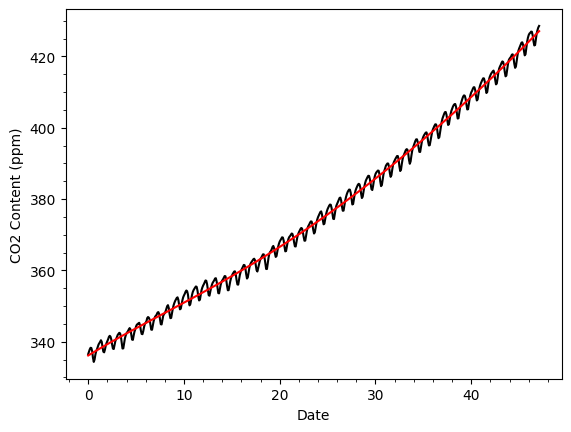

In [33]:
date_co2 = (df_CO2['dt'] - df_CO2['dt'].min()).dt.days/365.25 # Convert datetime to years since start
date_co2 =date_co2.to_numpy()
CO2 = df_CO2['average'].to_numpy()

order = 5 #set the polynomial order
pp = np.polyfit(date_co2,CO2,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,date_co2) #find the value of the polynomial at each time point.

plt.plot(date_co2,CO2,'k') #plot the data
plt.plot(date_co2,trend,'r') #plot the trend
plt.xlabel('Date') #label the x-axis
plt.ylabel('CO2 Content (ppm)') #label the y-axis
plt.minorticks_on() #add minorticks to the plot

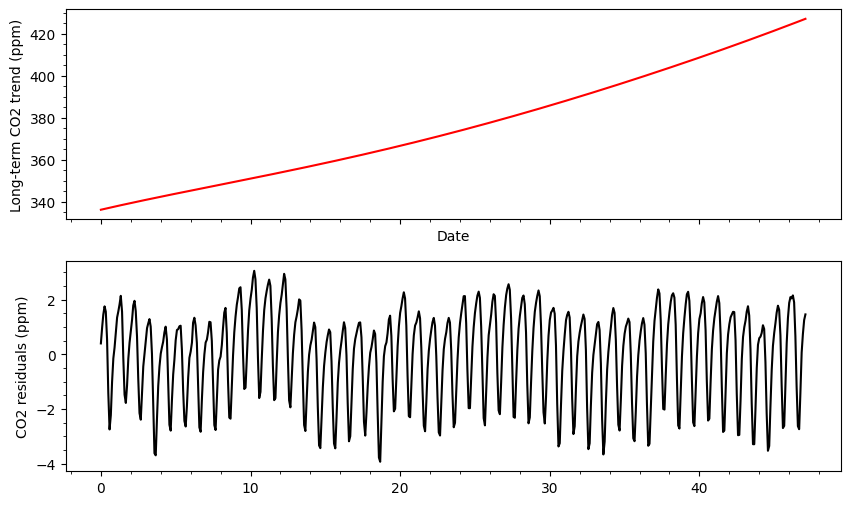

In [34]:
residuals = CO2-trend #find the residuals
fig, axes = plt.subplots(2,1, figsize=(10, 6), sharex = True) #make 2 subplots with the same x-axis

axes[0].plot(date_co2,trend,'r') #plot the polynomial trend
axes[1].plot(date_co2,residuals,'k') #plot the residuals

axes[0].set_xlabel('Date') #label the x-axis
axes[0].set_ylabel('Long-term CO2 trend (ppm)') #label the trend y-axis
axes[1].set_ylabel('CO2 residuals (ppm)') #label the residual y-axis

axes[0].minorticks_on() #add minorticks
axes[1].minorticks_on() #add minorticks

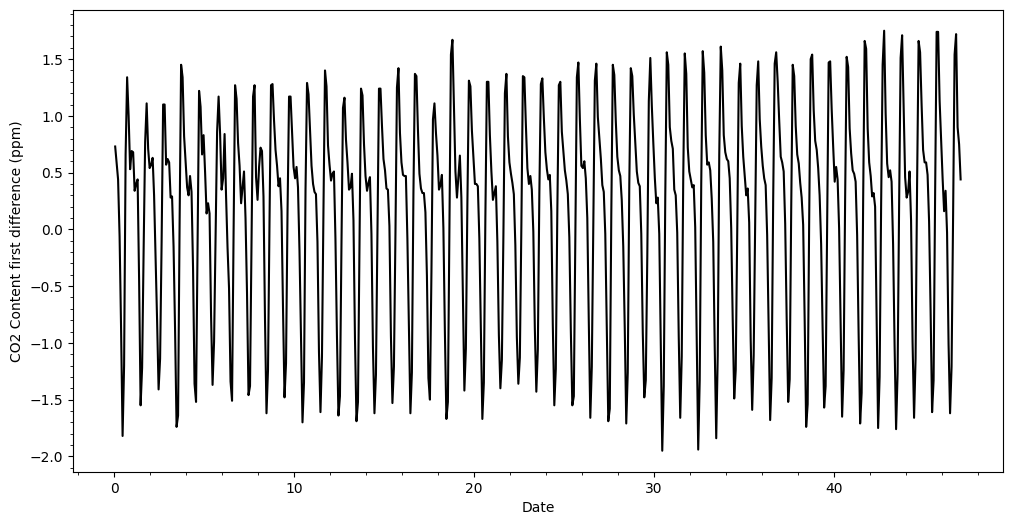

In [35]:
plt.figure(figsize=(12, 6))
co2_diff = np.diff(CO2) #difference between neighboring points
date_diff = (date_co2[:-1] + date_co2[1:])/2 #find the mid-point in time between points (needed for plotting)
plt.plot(date_diff,co2_diff,'k') #plot the differences
#plt.xlim([2000,2010]) #zoom in to see the details

plt.xlabel('Date') #label the x-axis
plt.ylabel('CO2 Content first difference (ppm)') #label the y-axis
plt.minorticks_on() #add minorticks

In [55]:
# ── Build seasonal predictors ─────────────────────────────────────────────────
sin_term = np.sin(2 * np.pi * date_co2)    # period = 1 year
cos_term = np.cos(2 * np.pi * date_co2)    # period = 1 year

# ── Linear regression: residuals = A*sin + B*cos ──────────────────────────────
# Stack into design matrix — no intercept (residuals already mean-zero)
X = np.column_stack([sin_term, cos_term])
coeffs, *_ = np.linalg.lstsq(X, residuals, rcond=None)
A_seas, B_seas = coeffs

# Convert to amplitude and phase
C_seas   = np.sqrt(A_seas**2 + B_seas**2)    # amplitude (ppm)
phi_seas = np.arctan2(B_seas, A_seas)          # phase (radians)

print(f"Seasonal amplitude : {C_seas:.4f} ppm")
print(f"Seasonal phase     : {phi_seas:.4f} rad")
print(f"  (equivalent to peak at t = {-phi_seas/(2*np.pi):.3f} yrs into year)")

seasonal_fit = A_seas * sin_term + B_seas * cos_term

Seasonal amplitude : 2.0393 ppm
Seasonal phase     : 0.5633 rad
  (equivalent to peak at t = -0.090 yrs into year)


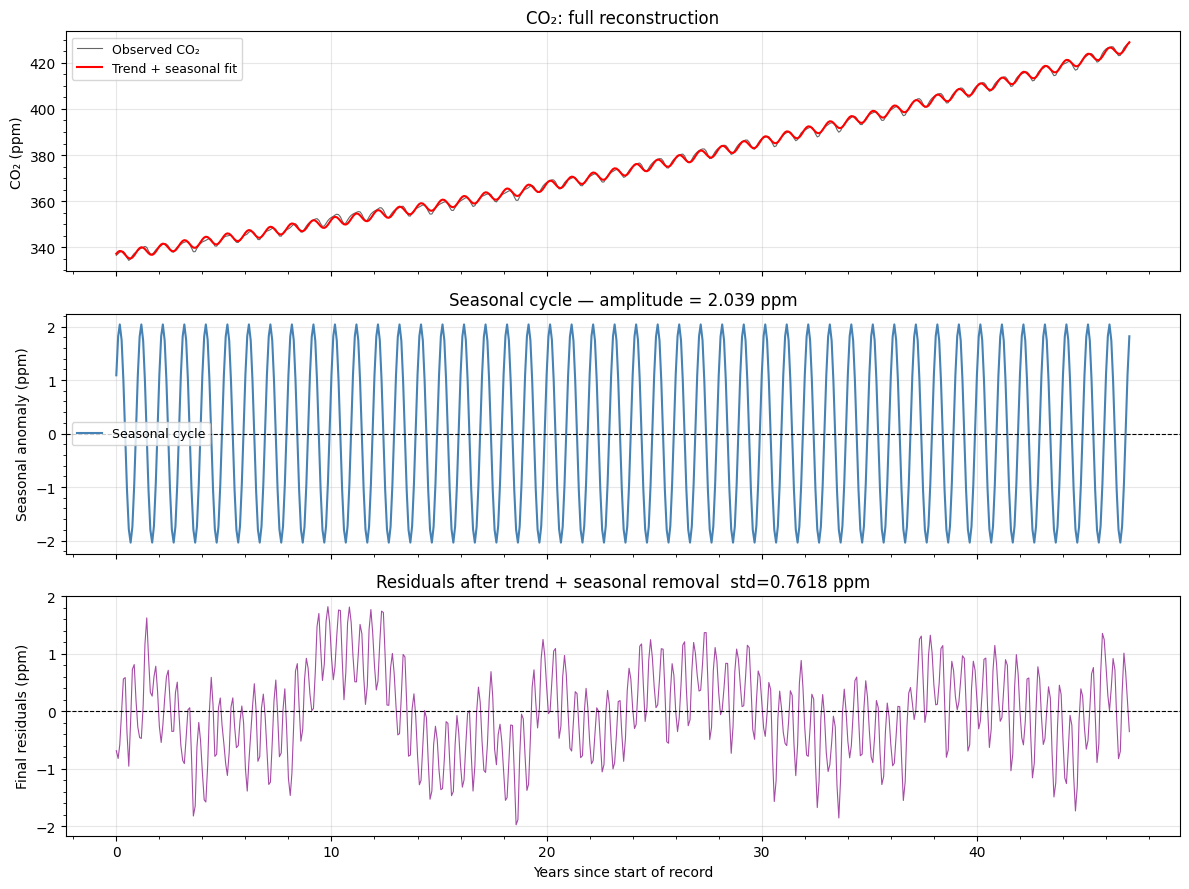

In [56]:
CO2_reconstructed = trend + seasonal_fit
residuals_final   = CO2 - CO2_reconstructed

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].plot(date_co2, CO2,               'k',  lw=0.8, alpha=0.6, label='Observed CO₂')
axes[0].plot(date_co2, CO2_reconstructed, 'r',  lw=1.5, label='Trend + seasonal fit')
axes[0].set_ylabel('CO₂ (ppm)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].minorticks_on()
axes[0].set_title('CO₂: full reconstruction')

axes[1].plot(date_co2, seasonal_fit, 'steelblue', lw=1.5, label='Seasonal cycle')
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_ylabel('Seasonal anomaly (ppm)')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].minorticks_on()
axes[1].set_title(f'Seasonal cycle — amplitude = {C_seas:.3f} ppm')

axes[2].plot(date_co2, residuals_final, 'purple', lw=0.8, alpha=0.7)
axes[2].axhline(0, color='k', lw=0.8, ls='--')
axes[2].set_ylabel('Final residuals (ppm)')
axes[2].set_xlabel('Years since start of record')
axes[2].grid(True, alpha=0.3)
axes[2].minorticks_on()
axes[2].set_title(f'Residuals after trend + seasonal removal  std={residuals_final.std():.4f} ppm')

plt.tight_layout()
plt.show()

In [57]:
def CO2_of_t(t):
    """
    Full CO₂ concentration as a function of time.
    t = years since start of observational record (date_co2[0]).

    Components:
      - Long-term trend: order-5 polynomial fitted to observations
      - Seasonal cycle:  amplitude and phase derived from residuals
    """
    trend_t    = np.polyval(pp, t)
    seasonal_t = A_seas * np.sin(2*np.pi*t) + B_seas * np.cos(2*np.pi*t)
    return trend_t + seasonal_t

# ── Print the full expression with numerical values ───────────────────────────
print("CO₂(t) = polynomial trend + seasonal cycle")
print(f"\nSeasonal component:")
print(f"  {A_seas:.4f}·sin(2πt) + {B_seas:.4f}·cos(2πt)")
print(f"  equivalent to {C_seas:.4f}·sin(2πt + {phi_seas:.4f})")
print(f"\nPolynomial trend coefficients (highest order first):")
for i, p in enumerate(pp):
    power = len(pp) - 1 - i
    print(f"  p[{i}] = {p:.6e}  (t^{power})")
print(f"\nFull expression:")
terms = ' + '.join([f'{p:.4e}·t^{len(pp)-1-i}' for i,p in enumerate(pp)])
print(f"  CO₂(t) = {terms}")
print(f"         + {A_seas:.4f}·sin(2πt) + {B_seas:.4f}·cos(2πt)")

CO₂(t) = polynomial trend + seasonal cycle

Seasonal component:
  1.7242·sin(2πt) + 1.0889·cos(2πt)
  equivalent to 2.0393·sin(2πt + 0.5633)

Polynomial trend coefficients (highest order first):
  p[0] = 2.186674e-07  (t^5)
  p[1] = -3.265602e-05  (t^4)
  p[2] = 1.867384e-03  (t^3)
  p[3] = -3.234823e-02  (t^2)
  p[4] = 1.647943e+00  (t^1)
  p[5] = 3.361585e+02  (t^0)

Full expression:
  CO₂(t) = 2.1867e-07·t^5 + -3.2656e-05·t^4 + 1.8674e-03·t^3 + -3.2348e-02·t^2 + 1.6479e+00·t^1 + 3.3616e+02·t^0
         + 1.7242·sin(2πt) + 1.0889·cos(2πt)


In [ ]:
#ΔF=OLR2−OLR1 ​=α⋅ln(C0/​CO2​​)

###Atmospheric Heat Capacity

In [192]:
Cp = 1004
delta_p1 = 30000
delta_p2 = 70000
g = 9.81
Ca1 = (Cp*delta_p1)/g
Ca2 = (Cp*delta_p2)/g
print(f"Ca1 = {Ca1:.4f} J/m^2 K")
print(f"Ca2 = {Ca2:.4f} J/m^2 K")

Ca1 = 3070336.3914 J/m^2 K
Ca2 = 7164118.2467 J/m^2 K


In [ ]:
#Ca = Cp/g * integral dp (J/K*m^2) or Ca = integral of ro *cp*dz
#where ro(z) = atm density, cp = specific heat capacity of air, dz = vertical layer thickness
# cp = J/kg*K
# VIT = (K * kg/m^2)
# VIT/Ta = (kg/m^2) -> * Cp = (J/K*m^2)

#dp = -rogdz -> Ca = Cp/g * integral dp -> Ca = (Cp*delta p)/g
#Ca = F_atm_net/(dT/dt)

###Solar Insolation via FFT

In [78]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal


def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs > cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

In [79]:
TSI = df_S['TSI'].values #get the values as a numpy array
age = np.arange(1, len(TSI) + 1)/365.25 #convert age into an array 1 to len

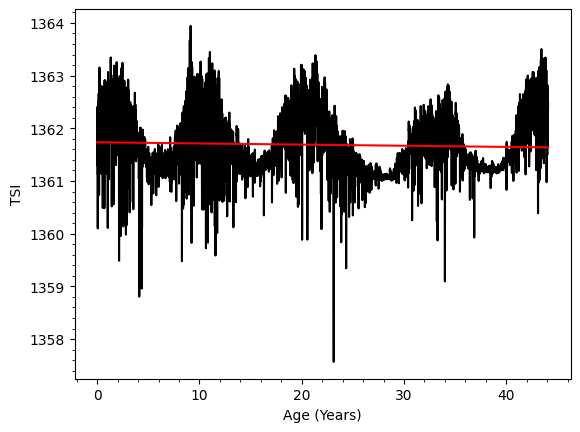

In [81]:
pp = np.polyfit(age,TSI,1) #fit a trendline to the data
plt.plot(age,TSI,'k') #plot the original data
plt.plot(age,np.polyval(pp,age),'r') #plot the trendline
plt.xlabel('Age (Years)') #label the x-axis
plt.ylabel('TSI') #label the y-axis
#plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

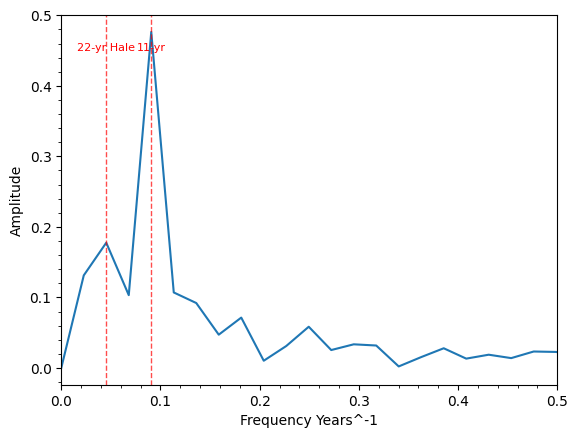

In [91]:
detrend = TSI-np.polyval(pp,age) #calculate the detrended data
freqs, amps = freq_spectrum(age,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency Years^-1') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.xlim([0,0.5]) #limits the x-axis
plt.minorticks_on() #add minorticks

for period, label in [(11, '11-yr'), (22, '22-yr Hale')]:
    plt.axvline(x=1/period, color='r', ls='--', lw=1, alpha=0.7)
    plt.text(1/period, plt.ylim()[1]*0.9, label, fontsize=8,
             ha='center', color='r')

#plt.gca().axvline(x=1/100,color='r') #mark eccentricity frequency

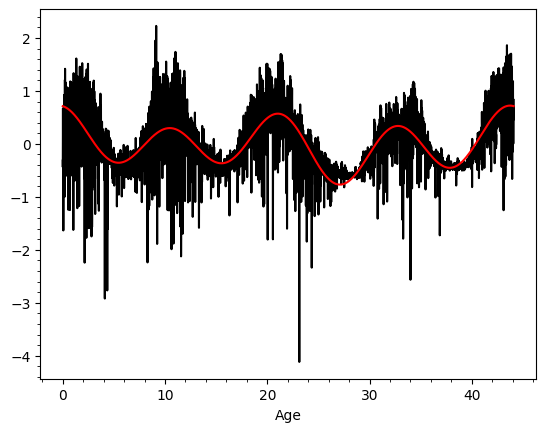

In [92]:
plt.plot(age,detrend,'k') #plot the detrended data
x, y = lowpass_filter(age,detrend,0.1) #obtain the filtered signal
plt.plot(x,y,'r') #plot the filtered signal
plt.xlabel('Age') #label the x-axis
#plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks

In [93]:
def bandpass_filter(time, signal, cutoff_range):
    n = len(time)
    x = np.linspace(np.min(time), np.max(time), n)
    y = np.interp(x, time, signal)

    sample_rate = 1 / (x[1] - x[0])
    fft_vals = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1/sample_rate)

    # Zero out frequencies outside the [low, high] range
    fft_vals[(freqs < cutoff_range[0]) | (freqs > cutoff_range[1])] = 0.0

    filtered_signal = np.fft.irfft(fft_vals, n=len(time))
    return x, filtered_signal

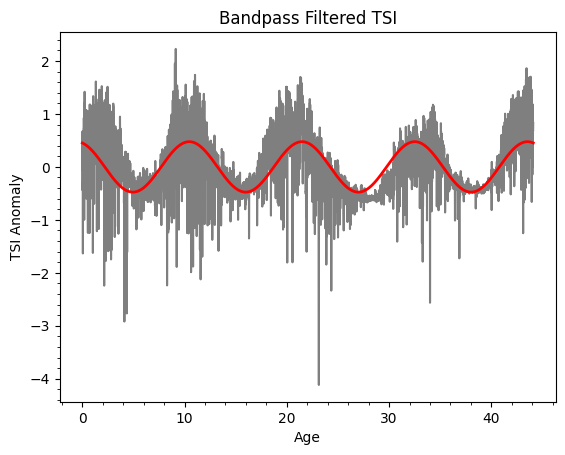

In [94]:
plt.plot(age, detrend, 'k', alpha=0.5) # plot the detrended data
x1, y1 = bandpass_filter(age, detrend, [0.085, 0.095]) # obtain the filtered signal
plt.plot(x1, y1, 'r', lw=2) # plot the filtered signal
plt.xlabel('Age') # label the x-axis
plt.ylabel('TSI Anomaly')
plt.title('Bandpass Filtered TSI')
#plt.xlim([0, 16000]) # adjusted for full dataset length
plt.minorticks_on()
plt.show()

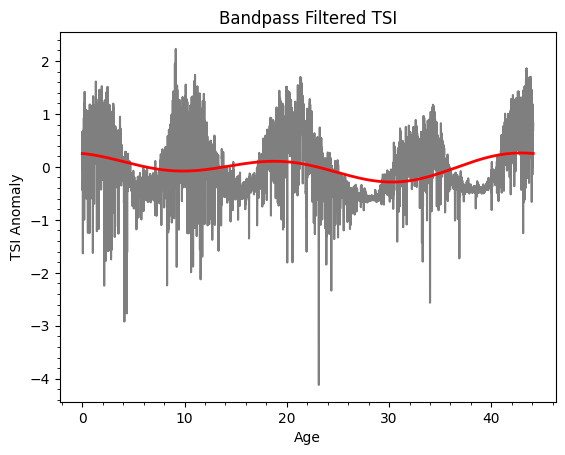

In [95]:
plt.plot(age, detrend, 'k', alpha=0.5) # plot the detrended data
x2, y2 = bandpass_filter(age, detrend, [0.02, 0.06]) # obtain the filtered signal
plt.plot(x2, y2, 'r', lw=2) # plot the filtered signal
plt.xlabel('Age') # label the x-axis
plt.ylabel('TSI Anomaly')
plt.title('Bandpass Filtered TSI')
#plt.xlim([0, 16000]) # adjusted for full dataset length
plt.minorticks_on()
plt.show()

In [182]:
   # S = S0 + A_cycle1 * np.sin(2 * np.pi * t / P_cycle1) + A_cycle2 * np.sin(2 * np.pi * t / P_cycle2)

In [178]:
S0 = pp[1]
freqs_11yr = np.argmin(np.abs(freqs - 1/11))
freqs_22yr = np.argmin(np.abs(freqs - 1/22))
A11 = amps[freqs_11yr]
A22 = amps[freqs_22yr]

# Perform a Real Fast Fourier Transform (RFFT) on the interpolated detrended TSI data 'y'.
fft_vals = np.fft.rfft(detrend)
# Calculate the frequencies corresponding to the FFT results. 'd' is the sample spacing.
all_freqs = np.fft.rfftfreq(len(age), d=(age[1]-age[0]))

# Extract the phase angle (in radians) of the FFT result
phi11 = np.angle(fft_vals[freqs_11yr])   # phase in radians
phi22 = np.angle(fft_vals[freqs_22yr])

cycle11 = A11 * np.sin(2*np.pi*age/11.0 + 1.9)
cycle22 = A22 * np.sin(2*np.pi*age/22.0 + 2.3)

S = S0  + cycle11 + cycle22

S0    = 1361.7344 W/m²
A_11  = 0.4765 W/m²
phi11 = 0.3221 rad
A_22  = 0.1776 W/m²
phi22 = 0.6044 rad


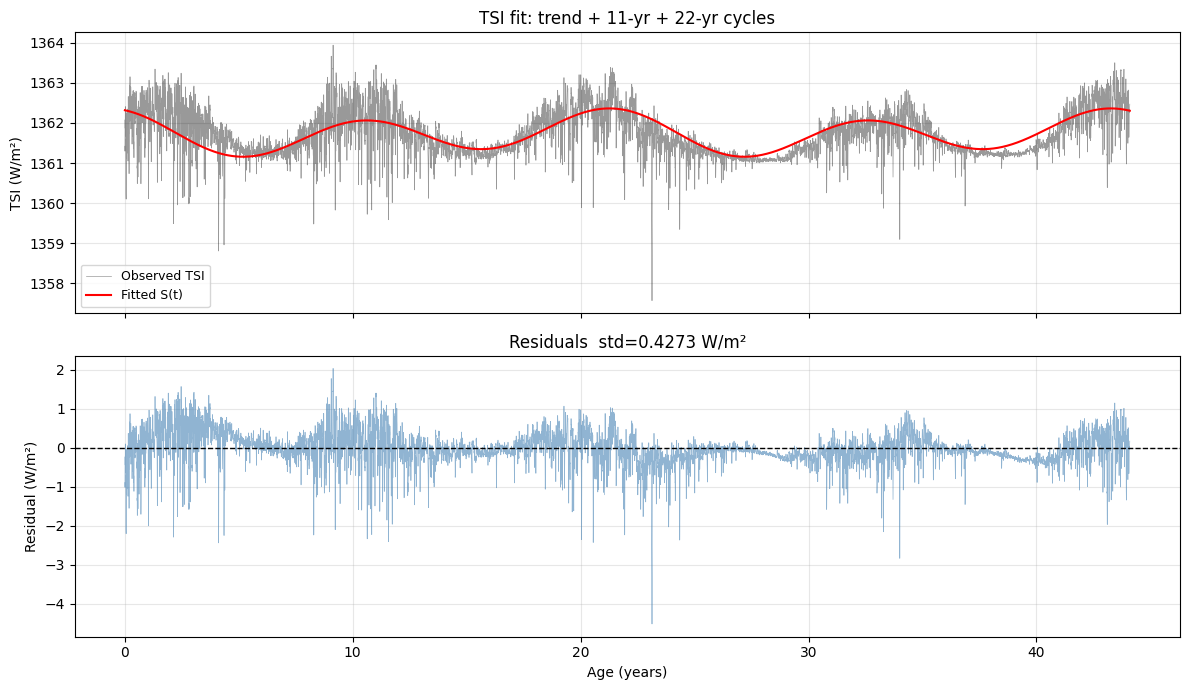

In [181]:
residuals = TSI - S

print(f"S0    = {S0:.4f} W/m²")
print(f"A_11  = {A11:.4f} W/m²")
print(f"phi11 = {phi11:.4f} rad")
print(f"A_22  = {A22:.4f} W/m²")
print(f"phi22 = {phi22:.4f} rad")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(age, TSI,      'k', lw=0.5, alpha=0.4, label='Observed TSI')
axes[0].plot(age, S, 'r', lw=1.5, label='Fitted S(t)')
axes[0].set_ylabel('TSI (W/m²)')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_title('TSI fit: trend + 11-yr + 22-yr cycles')

axes[1].plot(age, residuals, 'steelblue', lw=0.5, alpha=0.6)
axes[1].axhline(0, color='k', lw=1, ls='--')
axes[1].set_ylabel('Residual (W/m²)')
axes[1].set_xlabel('Age (years)')
axes[1].grid(True, alpha=0.3)
axes[1].set_title(f'Residuals  std={residuals.std():.4f} W/m²')

plt.tight_layout()
plt.show()

###Epsilon anylitical and numerical (regression)

In [ ]:
# Epsilon:
# Formula: OLR = sigma * Ts^4 * (1 - epsilon/2)
# Rearranged: epsilon = 2 * (1 - OLR / (sigma * Ts^4))
OLR_abs    = np.abs(df_tnlwrf['avg_tnlwrf'])               # ensure positive
epsilon_ts  = 2 * (1 - OLR_abs / (sigma * (df_Ts['Surface Temperature']+273.15)**4))
epsilon = epsilon_ts.mean()
epsilon_std = epsilon_ts.std()
print(f"epsilon = {epsilon:.4f} ± {epsilon_std:.4f}")

In [ ]:
# Align OLR and Surface Temperature datasets on the common 'dt' column
df_aligned = pd.merge(
    df_tnlwrf[['dt', 'avg_tnlwrf']],
    df_Ts[['dt', 'Surface Temperature']],
    on='dt'
).dropna()

# Calculate OLR and sigma*Ts^4 over the aligned time period
OLR = np.abs(df_aligned['avg_tnlwrf'])
radiated = sigma * (df_aligned['Surface Temperature'] + 273.15)**4

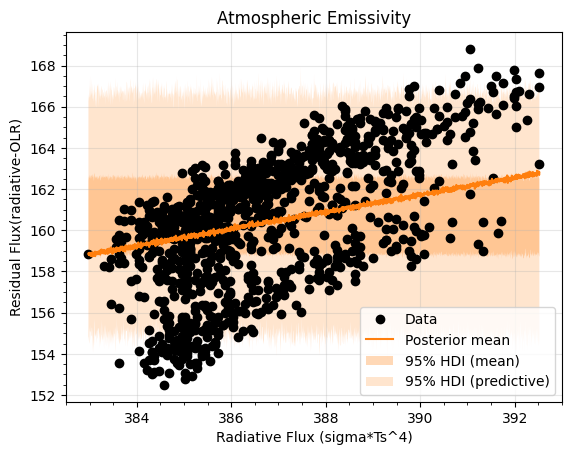

In [ ]:
data = pd.DataFrame({"y": radiated-OLR, "x": radiated})

# Fit Bayesian models
model_linear = bmb.Model("y ~ 0+x", data)
idata_linear = model_linear.fit(progressbar=False)

x_range = np.linspace(data['x'].min(), data['x'].max(), 2000)

new_data = pd.DataFrame({"x": x_range})
model_linear.predict(idata_linear, data=new_data, kind='response_params')
model_linear.predict(idata_linear, data=new_data, kind='response')

# Make random draws from the posterior of the regression lines
y_mean_draws = idata_linear.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Make random draws from the posterior of the gravel size
y_pps_draws = idata_linear.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(idata_linear.posterior["mu"].values.reshape(-1, len(x_range)), prob=0.95)
hdi_pps = az.hdi(y_pps_draws, prob=0.95)

# Plot both posterior for regression lines and the observations
plt.plot(data['x'], data['y'], 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI (mean)",
    edgecolor = None
)

plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.2,
    color="C1",
    label="95% HDI (predictive)",
    edgecolor = None
)

plt.legend()
plt.minorticks_on()
plt.xlabel('Radiative Flux (sigma*Ts^4)')
plt.ylabel('Residual Flux(radiative-OLR)')
plt.title('Atmospheric Emissivity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Extract slope (beta = epsilon/2) from posterior
beta  = idata_linear.posterior["x"].values.flatten()

# epsilon = 2 * beta
epsilon_samples = 2 * beta
epsilon_mean    = epsilon_samples.mean()
epsilon_hdi     = az.hdi(epsilon_samples, prob=0.95)

print(f"epsilon = {epsilon_mean:.4f} 95% HDI [{epsilon_hdi[0]:.4f}, {epsilon_hdi[1]:.4f}]")

epsilon = 0.2303 95% HDI [0.1496, 0.3207]


###Gamma1 and gamma2 anylitical and numerical (regression)

In [ ]:
# Gamma1:
# C_d1(dTd1/dt)=gamma1(Ts-Td1)-gamma2(Td1-Td2)
# gamma1 = [C_d1(dTd1/dt)+gamma2(Td1-Td2)]/(Ts-Td1)

# C_d2(dTd2/dt)=gamma2(Td1-Td2)
# gamma2 = [C_d2(dTd2/dt)]/(Td1-Td2)
# Td1-Td2 = (C_d2(dtd2/dt)/gamma2)
Td1_ref  = 275.0   # K  approximate 1981-2010 mean for 0-2000m
Td2_ref = 274.5   # K  approximate 1981-2010 mean for 2000-6000mTd1

In [ ]:
# Reference temperatures (K) to convert anomalies to absolute values
Td1_ref = 275.0
Td2_ref = 274.5

# Align datasets on the common 'dt' column
df_aligned = pd.merge(
    df_Ts[['dt', 'Surface Temperature']],
    df_Td1[['dt', 'Temperature']],
    on='dt'
)
df_aligned = pd.merge(
    df_aligned,
    df_Td2[['dt', 'Temperature']],
    on='dt',
    suffixes=('_Td1', '_Td2')
).dropna()

# Convert to absolute Kelvin
Ts = df_aligned['Surface Temperature'] + 273.15
Td1 = df_aligned['Temperature_Td1'] + Td1_ref
Td2 = df_aligned['Temperature_Td2'] + Td2_ref

In [ ]:
# Calculate derivatives (dT/dt in K/sec)
dTd2_dt = np.gradient(Td2, seconds_per_year / 12)  # monthly data
dTd1_dt = np.gradient(Td1, seconds_per_year / 12)

# C_d2 * dTd2/dt = gamma2 * (Td1 - Td2)
gamma2_series = (C_d2 * dTd2_dt) / (Td1 - Td2)
gamma2_final = gamma2_series.mean()

# C_d1 * dTd1/dt = gamma1 * (Ts - Td1) - gamma2 * (Td1 - Td2)
# gamma1 = [C_d1 * dTd1/dt + gamma2 * (Td1 - Td2)] / (Ts - Td1)
gamma1_series = (C_d1 * dTd1_dt + gamma2_final * (Td1 - Td2)) / (Ts - Td1)
gamma1_final = gamma1_series.mean()

print(f"Analytical gamma2: {gamma2_final:.4f} W/m^2/K")
print(f"Analytical gamma1: {gamma1_final:.4f} W/m^2/K")

Analytical gamma2: 0.5100 W/m^2/K
Analytical gamma1: 0.1036 W/m^2/K


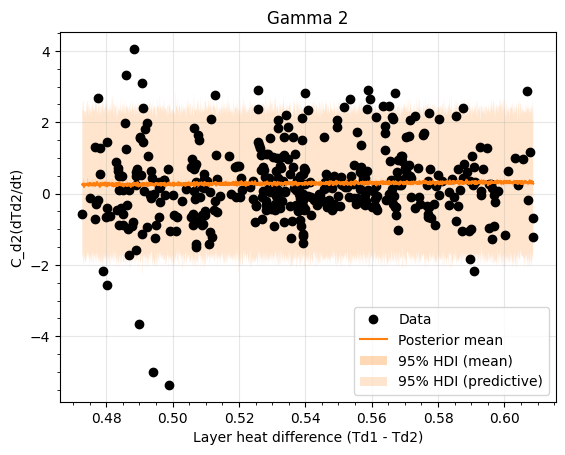

In [ ]:
data = pd.DataFrame({"y": C_d2 * np.gradient(Td2, seconds_per_year/12), "x": Td1-Td2})

# Fit Bayesian models
model_linear = bmb.Model("y ~ 0 + x", data)
idata_linear = model_linear.fit(progressbar=False)

x_range = np.linspace(data['x'].min(), data['x'].max(), 2000)

new_data = pd.DataFrame({"x": x_range})
model_linear.predict(idata_linear, data=new_data, kind='response_params')
model_linear.predict(idata_linear, data=new_data, kind='response')

# Make random draws from the posterior of the regression lines
y_mean_draws = idata_linear.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Make random draws from the posterior of the gravel size
y_pps_draws = idata_linear.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(idata_linear.posterior["mu"].values.reshape(-1, len(x_range)), prob=0.95)
hdi_pps = az.hdi(y_pps_draws, prob=0.95)

# Plot both posterior for regression lines and the observations
plt.plot(data['x'], data['y'], 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI (mean)",
    edgecolor = None
)

plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.2,
    color="C1",
    label="95% HDI (predictive)",
    edgecolor = None
)

plt.legend()
plt.minorticks_on()
plt.ylabel('C_d2(dTd2/dt)')
plt.xlabel('Layer heat difference (Td1 - Td2)')
plt.title('Gamma 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Extract slope (beta = ) from posterior
beta  = idata_linear.posterior["x"].values.flatten()

# gamma2 = 1/beta
gamma2_samples = beta
gamma2_mean    = gamma2_samples.mean()
gamma2_hdi     = az.hdi(gamma2_samples, prob=0.95)

print(f"gamma2 = {gamma2_mean:.4f} 95% HDI [{gamma2_hdi[0]:.4f}, {gamma2_hdi[1]:.4f}]")

gamma2 = 0.5304 95% HDI [0.3270, 0.7100]


In [ ]:
# C_d1 * dTd1/dt = gamma1 * (Ts - Td1) - gamma2 * (Td1 - Td2)

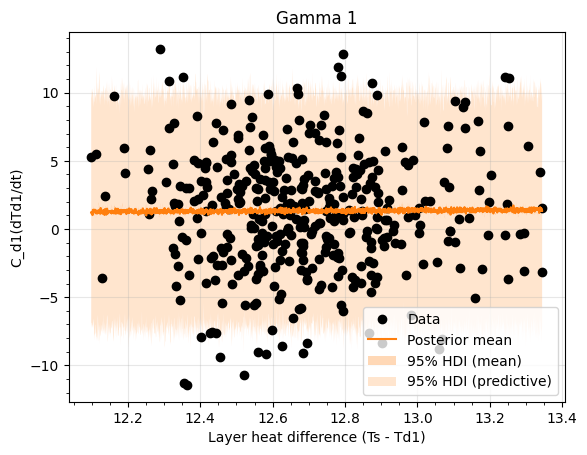

In [ ]:
data = pd.DataFrame({"y": C_d1 * np.gradient(Td1, seconds_per_year/12) + gamma2_mean * (Td1-Td2), "x": Ts-Td1})

# Fit Bayesian models
model_linear = bmb.Model("y ~ 0 + x", data)
idata_linear = model_linear.fit(progressbar=False)

x_range = np.linspace(data['x'].min(), data['x'].max(), 2000)

new_data = pd.DataFrame({"x": x_range})
model_linear.predict(idata_linear, data=new_data, kind='response_params')
model_linear.predict(idata_linear, data=new_data, kind='response')

# Make random draws from the posterior of the regression lines
y_mean_draws = idata_linear.posterior["mu"].values

# Reshape to (total_draws, x_points)
y_mean_draws = y_mean_draws.reshape(-1, len(x_range))

# Make random draws from the posterior predictive distribution
y_pps_draws = idata_linear.posterior_predictive["y"].values

# Reshape to (total_draws, x_points)
y_pps_draws = y_pps_draws.reshape(-1, len(x_range))

# Compute mean and HDI of the posterior predictive distribution
posterior_mean = y_pps_draws.mean(axis=0)
hdi_mean = az.hdi(idata_linear.posterior["mu"].values.reshape(-1, len(x_range)), prob=0.95)
hdi_pps = az.hdi(y_pps_draws, prob=0.95)

# Plot both posterior for regression lines and the observations
plt.plot(data['x'], data['y'], 'ok', label="Data")
plt.plot(x_range, posterior_mean, color="C1", label="Posterior mean")
plt.fill_between(
    x_range,
    hdi_mean[:, 0],
    hdi_mean[:, 1],
    alpha=0.3,
    color="C1",
    label="95% HDI (mean)",
    edgecolor = None
)

plt.fill_between(
    x_range,
    hdi_pps[:, 0],
    hdi_pps[:, 1],
    alpha=0.2,
    color="C1",
    label="95% HDI (predictive)",
    edgecolor = None
)

plt.legend()
plt.minorticks_on()
plt.xlabel('Layer heat difference (Ts - Td1)')
plt.ylabel('C_d1(dTd1/dt)')
plt.title('Gamma 1')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Extract slope (beta = ) from posterior
beta  = idata_linear.posterior["x"].values.flatten()

# gamma2 = 1/beta
gamma1_samples = beta
gamma1_mean    = gamma1_samples.mean()
gamma1_hdi     = az.hdi(gamma1_samples, prob=0.95)

print(f"gamma1 = {gamma1_mean:.4f} 95% HDI [{gamma1_hdi[0]:.4f}, {gamma1_hdi[1]:.4f}]")

gamma1 = 0.1047 95% HDI [0.0710, 0.1372]


###Albedo

In [ ]:
S0=1361
epsilon = 0.43
alpha_max = 0.79
alpha_min = 0.2

In [ ]:
def energy_balance(Ts_array, T_ice, delta_T):
    """
    Net energy flux at surface (W/m²).
    Positive = warming, negative = cooling, zero = equilibrium.
    """
    alpha = alpha_min + (alpha_max - alpha_min) / (
            1 + np.exp((Ts_array - T_ice) / delta_T))

    SW_absorbed = (1 - alpha) * S0 / 4
    OLR         = (2 - epsilon) / (2 + epsilon) * sigma * Ts_array**4

    return SW_absorbed - OLR

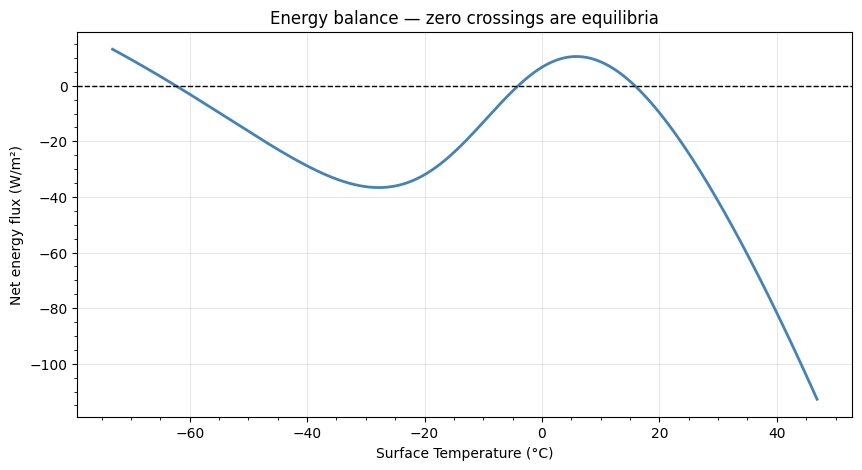

Number of equilibria: 3
  Equilibrium at Ts = -62.35 °C  (stable)
  Equilibrium at Ts = -4.06 °C  (unstable)
  Equilibrium at Ts = 15.83 °C  (stable)


In [ ]:
Ts_range = np.linspace(200, 320, 10000)

F = energy_balance(Ts_range, T_ice=265.0, delta_T=10.0)

plt.figure(figsize=(10, 5))
plt.plot(Ts_range - 273.15, F, 'steelblue', lw=2)
plt.axhline(0, color='k', lw=1, ls='--')
plt.xlabel('Surface Temperature (°C)')
plt.ylabel('Net energy flux (W/m²)')
plt.title('Energy balance — zero crossings are equilibria')
plt.grid(True, alpha=0.3)
plt.minorticks_on()
plt.show()

# Find and print zero crossings numerically
sign_changes = np.where(np.diff(np.sign(F)))[0]
print(f"Number of equilibria: {len(sign_changes)}")
for idx in sign_changes:
    # Linear interpolation to find crossing temperature
    T_eq = Ts_range[idx] - F[idx] * (Ts_range[idx+1] - Ts_range[idx]) / (F[idx+1] - F[idx])
    # Stability: if F goes from + to -, it's stable (system returns to it)
    #            if F goes from - to +, it's unstable (system moves away)
    stable = F[idx] > 0   # positive before crossing means stable
    print(f"  Equilibrium at Ts = {T_eq-273.15:.2f} °C  "
          f"({'stable' if stable else 'unstable'})")

T_ice range giving 3 equilibria: 256 – 277 K
                                 -17 – 4 °C
Central estimate: T_ice = 266.5 K  (-6.6 °C)


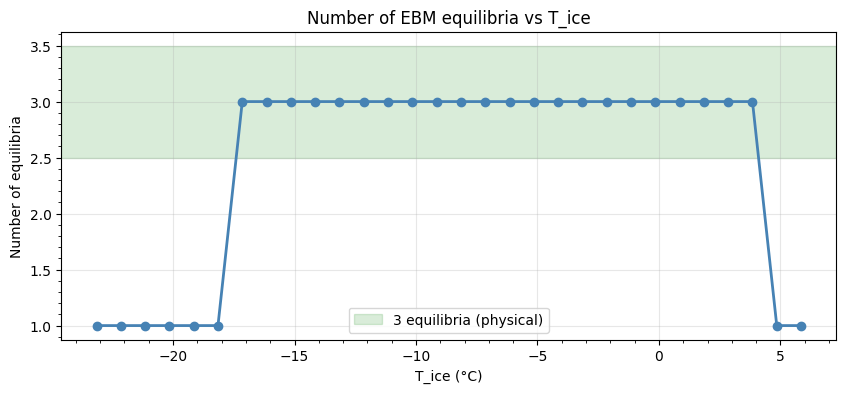

In [ ]:
T_ice_values = np.arange(250, 280, 1.0)
n_equilibria = []

for T_ice_test in T_ice_values:
    F_test       = energy_balance(Ts_range, T_ice_test, delta_T=10.0)
    sign_changes = np.where(np.diff(np.sign(F_test)))[0]
    n_equilibria.append(len(sign_changes))

n_equilibria = np.array(n_equilibria)

# Find the range of T_ice that gives 3 equilibria
mask_3eq     = n_equilibria == 3

if np.any(mask_3eq):
    T_ice_min    = T_ice_values[mask_3eq].min()
    T_ice_max    = T_ice_values[mask_3eq].max()
    T_ice_est    = T_ice_values[mask_3eq].mean()

    print(f"T_ice range giving 3 equilibria: {T_ice_min:.0f} – {T_ice_max:.0f} K")
    print(f"                                 {T_ice_min-273.15:.0f} – {T_ice_max-273.15:.0f} °C")
    print(f"Central estimate: T_ice = {T_ice_est:.1f} K  ({T_ice_est-273.15:.1f} °C)")
else:
    print("No T_ice values found in this range that produce exactly 3 equilibria.")
    print("Current max equilibria found:", n_equilibria.max())

# Plot the scan result
plt.figure(figsize=(10, 4))
plt.plot(T_ice_values - 273.15, n_equilibria, 'o-', color='steelblue', lw=2)
plt.axhspan(2.5, 3.5, alpha=0.15, color='green', label='3 equilibria (physical)')
plt.xlabel('T_ice (°C)')
plt.ylabel('Number of equilibria')
plt.title('Number of EBM equilibria vs T_ice')
plt.legend()
plt.grid(True, alpha=0.3)
plt.minorticks_on()
plt.show()

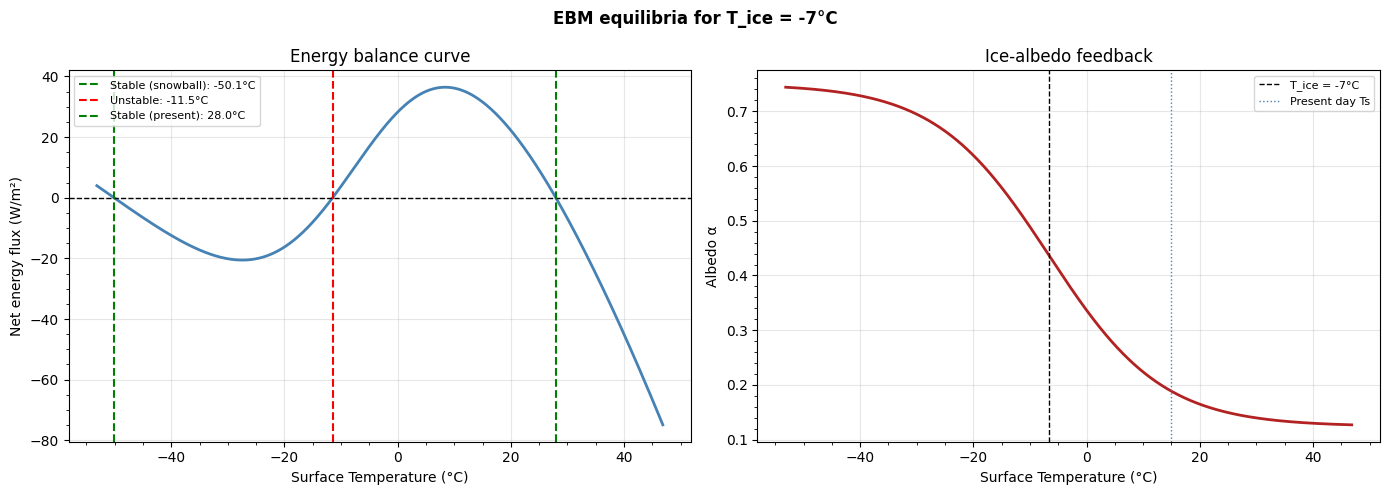

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'EBM equilibria for T_ice = {T_ice_est-273.15:.0f}°C', fontweight='bold')

# Left: energy balance curve with equilibria marked
F_best = energy_balance(Ts_range, T_ice_est, delta_T=10.0)
sign_changes = np.where(np.diff(np.sign(F_best)))[0]

axes[0].plot(Ts_range - 273.15, F_best, 'steelblue', lw=2)
axes[0].axhline(0, color='k', lw=1, ls='--')

colours = ['green', 'red', 'green']   # stable, unstable, stable
labels  = ['Stable (snowball)', 'Unstable', 'Stable (present)']
for j, idx in enumerate(sign_changes):
    T_eq = (Ts_range[idx] - F_best[idx]
            * (Ts_range[idx+1] - Ts_range[idx])
            / (F_best[idx+1] - F_best[idx]))
    axes[0].axvline(T_eq - 273.15, color=colours[j], ls='--', lw=1.5,
                    label=f'{labels[j]}: {T_eq-273.15:.1f}°C')

axes[0].set_xlabel('Surface Temperature (°C)')
axes[0].set_ylabel('Net energy flux (W/m²)')
axes[0].set_title('Energy balance curve')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)
axes[0].minorticks_on()

# Right: albedo curve showing transition
alpha_curve = alpha_min + (alpha_max - alpha_min) / (
              1 + np.exp((Ts_range - T_ice_est) / 10.0))
axes[1].plot(Ts_range - 273.15, alpha_curve, 'firebrick', lw=2)
axes[1].axvline(T_ice_est - 273.15, color='k', ls='--', lw=1,
                label=f'T_ice = {T_ice_est-273.15:.0f}°C')
axes[1].axvline(288 - 273.15, color='steelblue', ls=':', lw=1,
                label='Present day Ts')
axes[1].set_xlabel('Surface Temperature (°C)')
axes[1].set_ylabel('Albedo α')
axes[1].set_title('Ice-albedo feedback')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
axes[1].minorticks_on()

plt.tight_layout()
plt.show()

In [ ]:
alpha_min_phys = 0.12    # true ice-free albedo
alpha_max_phys = 0.60    # ice-covered albedo
delta_T_phys   = 10.0

# Solve alpha(288K) = 0.30 for T_ice:
# 0.30 = 0.12 + (0.60-0.12) / (1 + exp((288-T_ice)/10))
# (1 + exp((288-T_ice)/10)) = 0.48 / 0.18 = 2.667
# exp((288-T_ice)/10) = 1.667
# (288-T_ice)/10 = ln(1.667) = 0.511
# T_ice = 288 - 5.11 = 282.89 K

ratio      = (alpha_max_phys - alpha_min_phys) / (0.30 - alpha_min_phys)
T_ice_phys = 288 - delta_T_phys * np.log(ratio - 1)
print(f"T_ice for alpha(288K)=0.30: {T_ice_phys:.2f} K  ({T_ice_phys-273.15:.2f} °C)")

T_ice for alpha(288K)=0.30: 282.89 K  (9.74 °C)


#Model

## Setup

In [ ]:
# Define constants
sigma            = 5.67e-8
C_s = 0.7 * 1025 * 4000 * 50 + 0.3 * 1000 * 800 * 2
C_a1 = 0.7e7
C_a2 = 1.5e7
C_d = 1025 * 4000 * 3800              # ≈ 1.56e10 J/m²/K  deep ocean
C0              = 280
CO2_growth_rate = 2.0
epsilon         = 0.484
gamma           = 0.5                  # W/m²/K  surface–deep ocean exchange
alpha_min = 0.245
alpha_max = 0.80
T_ice     = 263.15   # K — centre of ice transition (~-10°C)
delta_T   = 10.0     # K — transition width
A_cycle = 0.5    # W/m²  — amplitude (half of ~1 W/m² peak-to-peak observed TSI range)
P_cycle = 11.0   # years — solar cycle period
S0 = 1361
eruption_probability = 0.01   # chance per timestep

In [ ]:
# Initialise time steps

years   = 1000
dt      = 0.001
n_steps = int(years / dt)
seconds_per_year = 365 * 24 * 3600
dt_sec  = dt * seconds_per_year
time    = np.linspace(0, years, n_steps)

##Model

In [ ]:
# Initialise arrays

Ts  = np.zeros(n_steps)
Ta2 = np.zeros(n_steps)
Ta1 = np.zeros(n_steps)
Td  = np.zeros(n_steps)               # deep ocean
F_volc = np.zeros(n_steps)

for i in range(n_steps):

    # Random eruption occurs
    if np.random.rand() < eruption_probability * dt:

        # One-sided normal distribution for strength (always negative cooling)
        strength = -np.abs(np.random.normal(loc=0, scale=2.5))
        strength = np.clip(strength, -8, -0.1)

        # Recovery timescale (years)
        tau = np.random.uniform(1, 3)

        # Apply exponential decay
        for j in range(i, n_steps):

            t_since = time[j] - time[i]

            F_volc[j] += strength * np.exp(-t_since / tau)


Ts[0]  = 287.41
Ta2[0] = 252.69
Ta1[0] = 229.07
Td[0]  = 277.41                        # 4°C — observed deep ocean mean

for i in range(n_steps - 1):
    t     = time[i]
    S = S0 + A_cycle * np.sin(2 * np.pi * t / P_cycle)

    alpha = alpha_max - (
    (alpha_max - alpha_min)
    / (1 + np.exp(-(Ts[i] - T_ice)/delta_T)))

    CO2   = C0 + CO2_growth_rate * t
    if CO2 < 1:
       CO2 = 1
    F_co2 = 5.35 * np.log(CO2 / C0)

    noise = np.random.normal(0, 7)

    dTs_dt = (
          (1 - alpha) * S / 4
        + epsilon * sigma * Ta2[i]**4
        + (1 - epsilon) * epsilon * sigma * Ta1[i]**4
        - sigma * Ts[i]**4
        + F_co2
        - gamma1 * (Ts[i] - Td[i])
        + F_volc[i]
        + noise
      ) / C_s

    dTa2_dt = (
          epsilon * sigma * Ts[i]**4
        + epsilon**2 * sigma * Ta1[i]**4
        - 2 * epsilon * sigma * Ta2[i]**4
      ) / C_a2

    dTa1_dt = (
          epsilon * (1 - epsilon) * sigma * Ts[i]**4
        + epsilon**2 * sigma * Ta2[i]**4
        - 2 * epsilon * sigma * Ta1[i]**4
      ) / C_a1

    dTd_dt = (
        gamma * (Ts[i] - Td[i])        # slow equilibration toward surface
      ) / C_d

    Ts[i+1]  = Ts[i]  + dTs_dt  * dt_sec
    Ta2[i+1] = Ta2[i] + dTa2_dt * dt_sec
    Ta1[i+1] = Ta1[i] + dTa1_dt * dt_sec
    Td[i+1]  = Td[i]  + dTd_dt  * dt_sec

##Visualisation

In [ ]:
# Plot model

plt.figure(figsize=(12, 6))

plt.plot(time, Ts - 273.15, label='Surface')
#plt.plot(time, Ta2 - 273.15, label='Ta2')
#plt.plot(time, Ta1 - 273.15, label='Ta1')
#plt.plot(time, Td - 273.15, label='Deep Ocean')
plt.xlim(0,years)
plt.xlabel('Time (years)')
plt.ylabel('Temperature (°C)')
plt.title('Earth Energy Balance Model')

plt.legend()
plt.grid(True)

plt.show()